In [1]:
import pandas as pd
import scanpy as sc
import h5py
import numpy as np
import anndata as ad

In [2]:
import numpy as np
import pandas as pd
from scipy import stats, sparse
import bottleneck


def run_egad(go, nw, **kwargs):
    """EGAD running function

    Wrapper to lower level functions for EGAD

    EGAD measures modularity of gene lists in co-expression networks.

    This was translated from the MATLAB version, which does tiled Cross Validation

    Two lines carry `# pandas 3` / `nan_policy` fixes for modern pandas and scipy; both
    are marked with a comment and neither changes the arithmetic.

    The useful kwargs are:
    int - nFold : Number of CV folds to do, default is 3,
    int - {min,max}_count : limits for number of terms in each gene list, these are exclusive values


    Arguments:
        go {pd.DataFrame} -- dataframe of genes x terms of values [0,1], where 1 is included in gene lists
        nw {pd.DataFrame} -- dataframe of co-expression network, genes x genes
        **kwargs

    Returns:
        pd.DataFrame -- dataframe of terms x metrics where the metrics are
        ['AUC', 'AVG_NODE_DEGREE', 'DEGREE_NULL_AUC', 'P_Value']
    """
    assert nw.shape[0] == nw.shape[1], "Network is not square"
    assert np.all(
        nw.index == nw.columns
    ), "Network index and columns are not in the same order"
    nw_mask = (nw.isna().sum(axis=1) != nw.shape[1]).to_numpy()
    kept = nw.index[nw_mask]
    # pandas 3 copy-on-write hands back read-only arrays from `.values`, so the diagonal
    # goes onto an explicit writable copy rather than in place. Before pandas 3 this was
    # `nw = nw.loc[nw_mask, nw_mask].astype(float)` / `np.fill_diagonal(nw.values, 1)`.
    values = nw.loc[kept, kept].to_numpy(dtype=float, copy=True)
    np.fill_diagonal(values, 1)
    nw = pd.DataFrame(values, index=kept, columns=kept)
    return _runNV(go, nw, **kwargs)


def _runNV(go, nw, nFold=3, min_count=20, max_count=1000):

    # Make sure genes are same in go and nw
    genes_intersect = go.index.intersection(nw.index)

    go = go.loc[genes_intersect, :]
    nw = nw.loc[genes_intersect, genes_intersect]

    # Make sure there aren't duplicates
    duplicates = nw.index.duplicated(keep="first")
    nw = nw.loc[~duplicates, ~duplicates]

    go = go.loc[:, (go.sum(axis=0) > min_count) & (go.sum(axis=0) < max_count)]
    go = go.loc[~go.index.duplicated(keep="first"), :]

    roc = _new_egad(go.values, nw.values, nFold)

    col_names = ["AUC", "AVG_NODE_DEGREE", "DEGREE_NULL_AUC", "P_Value"]
    # Put output in dataframe
    return pd.DataFrame(dict(zip(col_names, roc)), index=go.columns)


def _new_egad(go, nw, nFold):

    # Build Cross validated Positive
    x, y = np.where(go)
    cvgo = {}
    for i in np.arange(nFold):
        a = x[i::nFold]
        b = y[i::nFold]
        dat = np.ones_like(a)
        mask = sparse.coo_matrix((dat, (a, b)), shape=go.shape)
        cvgo[i] = go - mask.toarray()

    CVgo = np.concatenate(list(cvgo.values()), axis=1)

    sumin = np.matmul(nw.T, CVgo)

    degree = np.sum(nw, axis=0)

    predicts = sumin / degree[:, None]

    np.place(predicts, CVgo > 0, np.nan)

    # Calculate ranks of positives.
    # `nan_policy="omit"` is scipy >= 1.10's name for the behaviour this was written
    # against: rank the real values 1..n and leave the NaNs -- the held-in positives,
    # masked back out on the next line -- out of it. Since 1.10 the default is
    # "propagate", which returns an *all-NaN* array instead, so every rank sum comes out
    # 0 and every AUC collapses to the constant -(n_p + 1) / (2 * n_n). No exception is
    # raised, so leaving this off looks like a network with no structure in it.
    rank_abs = lambda x: stats.rankdata(np.abs(x), nan_policy="omit")
    predicts2 = np.apply_along_axis(rank_abs, 0, predicts)

    # Masking Nans that were ranked (how tiedrank works in matlab)
    predicts2[np.isnan(predicts)] = np.nan

    filtering = np.tile(go, nFold)

    # negatives :filtering == 0
    # Sets Ranks of negatives to 0
    np.place(predicts2, filtering == 0, 0)

    # Sum of ranks for each prediction
    p = bottleneck.nansum(predicts2, axis=0)

    # Number of predictions
    # Number of 1's masked for each GO term for each CV
    n_p = np.sum(filtering, axis=0) - np.sum(CVgo, axis=0)

    # Number of negatives
    # Number of GO terms - number of postiive
    n_n = filtering.shape[0] - np.sum(filtering, axis=0)

    roc = (p / n_p - (n_p + 1) / 2) / n_n
    U = roc * n_p * n_n
    Z = (np.abs(U - (n_p * n_n / 2))) / np.sqrt(n_p * n_n * (n_p + n_n + 1) / 12)
    roc = roc.reshape(nFold, go.shape[1])
    Z = Z.reshape(nFold, go.shape[1])
    # Stouffer Z method
    Z = bottleneck.nansum(Z, axis=0) / np.sqrt(nFold)
    # Calc ROC of Neighbor Voting
    roc = bottleneck.nanmean(roc, axis=0)
    P = stats.norm.sf(Z)

    # Average degree for nodes in each go term
    avg_degree = degree.dot(go) / np.sum(go, axis=0)

    # Calc null auc for degree
    ranks = np.tile(stats.rankdata(degree), (go.shape[1], 1)).T

    np.place(ranks, go == 0, 0)

    n_p = bottleneck.nansum(go, axis=0)
    nn = go.shape[0] - n_p
    p = bottleneck.nansum(ranks, axis=0)

    roc_null = (p / n_p - ((n_p + 1) / 2)) / nn

    return roc, avg_degree, roc_null, P

# GO term modularity, scored against the current NCBI annotation

Same analysis as
[`EGAD_eval_metacells.ipynb`](EGAD_eval_metacells.ipynb) - EGAD neighbour voting over the
metacells2 co-expression network - but the GO annotations come from **NCBI `gene2go`**
instead of the Phytozome `glyma.Wm82.gnm4.ann1.T8TQ.info_annot.txt` file, which dates to
**2019**.

That age is the reason for this notebook. Six years of GO curation sit between the two, and
`info_annot` was thin to begin with: only 8,836 of the network's 22,123 genes carried a
biological process or cellular component term, and only 87 terms had enough genes to score.

| | Phytozome `info_annot` (2019) | NCBI `gene2go` (current) |
| --- | --- | --- |
| Gene IDs | `Glyma.01G161700` - matches the network after a suffix append | NCBI `GeneID` - needs `gene_info`'s `LocusTag` as a bridge |
| Ontology per term | not recorded; taken from `go-basic.obo` | recorded directly in the `Category` column |
| Term names | not recorded | recorded in `GO_term` |

**Gene ID mapping.** The network is keyed on Phytozome IDs and `gene2go` on NCBI `GeneID`s,
which share nothing textually. `Glycine_max_3847.gene_info.csv` bridges them through its
`LocusTag` field, which carries Wm82.**a4** gene models - the same assembly the network is
built on, so no liftover is needed:

```
Glyma.01G161700.Wm82.a4.v1  ->  GLYMA_01G161700v4  ->  GeneID 100808170
```

This is the same `glyma_to_locustag` conversion the conservation notebook uses; only the
column it looks up differs (`GeneID` here, `Symbol` there).

Everything downstream - the ontology filter, the term-size bounds, the network, the
propagation step - is unchanged, so the two notebooks' numbers are directly comparable. The
last section does that comparison.

## Step 1 - subset `gene2go` to *Glycine max*

`gene2go.txt` is ~11 GB (every species NCBI annotates), so it is streamed in chunks, filtered
to taxid 3847, and cached next to the `gene_info` subset the conservation notebook made.
Re-runs read the cache.

In [3]:
import os
import urllib.request

import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_SEED = 476
np.random.seed(RANDOM_SEED)  # EGAD's CV folds are deterministic; set for consistency

NCBI_DIR = r"C:\Users\mikep\Data\NCBI"
REFERENCE_DIR = r"C:\Users\mikep\Data\Soybean\Soybean_reference_info"
METACELLS_DIR = r"C:\Users\mikep\Data\Soybean\Metacells_approaches\Metacells2"

GENE2GO_ALL = os.path.join(NCBI_DIR, "gene2go.txt")
GENE2GO_SOY = os.path.join(NCBI_DIR, "Glycine_max_3847.gene2go.csv")
GENE_INFO_SOY = os.path.join(NCBI_DIR, "Glycine_max_3847.gene_info.csv")
OBO_PATH = os.path.join(REFERENCE_DIR, "go-basic.obo")
NETWORK_PATH = os.path.join(
    METACELLS_DIR, "metacells2_505_metacell_coexpression_network.h5"
)
RESULTS_PATH = "metacells2_GO_egad_results_ncbi.csv"
PROPAGATED_RESULTS_PATH = "metacells2_GO_egad_results_ncbi_propagated.csv"

# The two runs of the Phytozome notebook, for the comparison at the end.
PHYTOZOME_RESULTS_PATH = "metacells2_GO_egad_results.csv"
PHYTOZOME_PROPAGATED_PATH = "metacells2_GO_egad_results_propagated.csv"
# Reported by step 3 of that notebook; the CSVs are per-term and do not carry it.
PHYTOZOME_ANNOTATED_GENES = 8836

GUARD_CELL_GENES_PATH = os.path.join(REFERENCE_DIR, "Guard_cell_genes.csv")
NETWORK_LABEL = "metacells2 (505 metacells)"

GLYCINE_MAX_TAXID = 3847
KEEP_CATEGORIES = ("Process", "Component")  # gene2go's names for BP and CC
CATEGORY_TO_NAMESPACE = {
    "Process": "biological_process",
    "Component": "cellular_component",
    "Function": "molecular_function",
}
N_FOLD = 3
MIN_COUNT, MAX_COUNT = 10, 500  # exclusive bounds on term size
READ_CHUNK_ROWS = 500  # rows per slab when pulling the network off disk

if os.path.exists(GENE2GO_SOY):
    gene2go = pd.read_csv(GENE2GO_SOY, dtype=str)
    print(f"Loaded cached Glycine max gene2go: {len(gene2go):,} rows")
else:
    print(f"Streaming {GENE2GO_ALL} and filtering to taxid {GLYCINE_MAX_TAXID} ...")
    kept = []
    for chunk in pd.read_csv(
        GENE2GO_ALL, sep="\t", dtype=str, chunksize=1_000_000, low_memory=False
    ):
        chunk = chunk.rename(columns={"#tax_id": "tax_id"})
        kept.append(chunk[chunk["tax_id"] == str(GLYCINE_MAX_TAXID)])
    gene2go = pd.concat(kept, ignore_index=True)
    gene2go.to_csv(GENE2GO_SOY, index=False)
    print(f"Cached {len(gene2go):,} Glycine max rows to {GENE2GO_SOY}")

print(
    f"\n{gene2go['GeneID'].nunique():,} genes, {gene2go['GO_ID'].nunique():,} GO terms"
)
print(gene2go["Category"].value_counts().to_string())
print(f"\nEvidence codes: {gene2go['Evidence'].value_counts().to_dict()}")
gene2go.head()

Loaded cached Glycine max gene2go: 110,380 rows

35,092 genes, 3,946 GO terms
Category
Function     48564
Process      35099
Component    26717

Evidence codes: {'IEA': 110380}


,tax_id,GeneID,GO_ID,Evidence,Qualifier,GO_term,PubMed,Category
0,3847,547449,GO:0004568,IEA,enables,chitinase activity,30032202,Function
1,3847,547449,GO:0005576,IEA,located_in,extracellular region,30032202,Component
2,3847,547449,GO:0005975,IEA,involved_in,carbohydrate metabolic process,22301074,Process
3,3847,547450,GO:0046872,IEA,enables,metal ion binding,30032202,Function
4,3847,547451,GO:0006952,IEA,involved_in,defense response,22301074,Process


## Step 2 - map NCBI `GeneID`s onto the network's gene names

`gene_info`'s `LocusTag` is the bridge. The conversion runs network-side (`Glyma...` ->
`GLYMA_...v4`) rather than the other way, because 18,328 of the 59,141 `gene_info` rows carry
no `LocusTag` at all (`-`) and would need dropping either way, and because a handful of the
real ones are organellar or unanchored (`GlmaCp081`, `GLYMA_U031413v4`) and simply will not
match a nuclear gene model.

In [4]:
gene_info = pd.read_csv(GENE_INFO_SOY, dtype=str)
print(f"gene_info: {len(gene_info):,} rows")

has_locus_tag = gene_info["LocusTag"] != "-"
print(f"  {int((~has_locus_tag).sum()):,} rows have no LocusTag and are dropped")
locus_to_geneid = (
    gene_info[has_locus_tag].drop_duplicates("LocusTag").set_index("LocusTag")["GeneID"]
)
print(f"  LocusTag -> GeneID entries: {len(locus_to_geneid):,}")


def glyma_to_locustag(gene):
    """Glyma.01G161700.Wm82.a4.v1 -> GLYMA_01G161700v4 (the NCBI LocusTag form)."""
    core = gene.split(".Wm82")[0]  # Glyma.01G161700
    return "GLYMA_" + core.split(".", 1)[1] + "v4"


with h5py.File(NETWORK_PATH, "r") as handle:
    network_genes = handle["genes"].asstr()[:]
network_position = pd.Series(np.arange(len(network_genes)), index=network_genes)
print(f"\nNetwork: {len(network_genes):,} genes, e.g. {network_genes[0]}")

gene_to_geneid = pd.Series(
    [glyma_to_locustag(gene) for gene in network_genes], index=network_genes
).map(locus_to_geneid)
mapped = gene_to_geneid.dropna()
print(
    f"  {len(mapped):,} map to an NCBI GeneID "
    f"({len(mapped) / len(network_genes):.1%}); {int(gene_to_geneid.isna().sum()):,} do not"
)
assert not mapped.duplicated().any(), "two network genes share a GeneID"

gene_info: 59,141 rows
  18,328 rows have no LocusTag and are dropped
  LocusTag -> GeneID entries: 40,813

Network: 22,123 genes, e.g. Glyma.01G161700.Wm82.a4.v1
  20,510 map to an NCBI GeneID (92.7%); 1,613 do not


## Step 3 - keep Process and Component

`gene2go` records the ontology itself, in `Category`, so unlike the Phytozome file this does
not need `go-basic.obo` to decide what is what. The obo is still parsed - for term names on
obsolete entries, for `alt_id` remapping, and for the `is_a` / `part_of` edges the propagation
step needs.

`NOT` qualifiers (an explicit statement that a gene does *not* do something) would have to be
excluded; soybean happens to have none, but the filter is applied rather than assumed.

In [5]:
if not os.path.exists(OBO_PATH):
    # geneontology.org rejects the default urllib agent with a 403.
    print(f"Downloading go-basic.obo to {OBO_PATH} ...")
    request = urllib.request.Request(
        "https://current.geneontology.org/ontology/go-basic.obo",
        headers={"User-Agent": "Mozilla/5.0"},
    )
    with urllib.request.urlopen(request, timeout=120) as response, open(
        OBO_PATH, "wb"
    ) as handle:
        handle.write(response.read())


def parse_obo(path):
    """Pull per-term metadata and the parent edges of the GO DAG out of an OBO file.

    Returns id -> name, id -> namespace, alt_id -> id, the set of obsolete ids, and
    id -> {parent ids}. The parents come from `is_a` and `part_of`, the two relations GO
    annotations propagate over; they are unused until step 6.
    """
    names, namespaces, alt_ids, obsolete, parents = {}, {}, {}, set(), {}
    part_of = "relationship: part_of "
    term_id, in_term = None, False
    with open(path) as handle:
        for line in handle:
            line = line.rstrip("\n")
            if line.startswith("["):  # [Term], [Typedef], ...
                in_term, term_id = line == "[Term]", None
            elif in_term:
                if line.startswith("id: "):
                    term_id = line[4:]
                    parents.setdefault(term_id, set())
                elif line.startswith("name: "):
                    names[term_id] = line[6:]
                elif line.startswith("namespace: "):
                    namespaces[term_id] = line[11:]
                elif line.startswith("alt_id: "):
                    alt_ids[line[8:]] = term_id
                elif line == "is_obsolete: true":
                    obsolete.add(term_id)
                elif line.startswith("is_a: "):  # "is_a: GO:0009521 ! photosystem"
                    parents[term_id].add(line[6:].split(" ! ")[0])
                elif line.startswith(part_of):
                    parents[term_id].add(line[len(part_of) :].split(" ! ")[0])
    return names, namespaces, alt_ids, obsolete, parents


go_name, go_namespace, go_alt_id, go_obsolete, go_parents = parse_obo(OBO_PATH)
print(
    f"go-basic.obo: {len(go_namespace):,} terms, {len(go_alt_id):,} alt_ids, "
    f"{len(go_obsolete):,} obsolete, "
    f"{sum(len(p) for p in go_parents.values()):,} is_a / part_of edges"
)

go-basic.obo: 48,340 terms, 3,646 alt_ids, 10,248 obsolete, 63,726 is_a / part_of edges


In [6]:
annotations = gene2go[gene2go["Category"].isin(KEEP_CATEGORIES)].copy()
print(
    f"Process + Component: {len(annotations):,} rows "
    f"({len(gene2go) - len(annotations):,} Function rows dropped)"
)

negated = annotations["Qualifier"].fillna("").str.contains("NOT")
print(f"  NOT-qualified annotations excluded: {int(negated.sum()):,}")
annotations = annotations[~negated]

# Attach the network gene name, and remap GO IDs that have been merged into another term.
geneid_to_gene = pd.Series(mapped.index, index=mapped.to_numpy())
annotations["gene"] = annotations["GeneID"].map(geneid_to_gene)
annotations = annotations.dropna(subset=["gene"])
annotations["GO"] = annotations["GO_ID"].map(lambda term: go_alt_id.get(term, term))
annotations["namespace"] = annotations["Category"].map(CATEGORY_TO_NAMESPACE)

# gene2go's own GO_term text is kept where the obo has nothing (obsolete or retired ids).
go_term_text = annotations.drop_duplicates("GO").set_index("GO")["GO_term"].to_dict()
term_name = {term: go_name.get(term, go_term_text.get(term)) for term in go_term_text}

gene_go = annotations[["gene", "GO", "namespace"]].drop_duplicates(ignore_index=True)
print(
    f"\n{len(gene_go):,} gene-GO pairs over {gene_go['gene'].nunique():,} network genes "
    f"and {gene_go['GO'].nunique():,} terms"
)
print(gene_go["namespace"].value_counts().to_string())

# Sanity check: Category and the obo should agree wherever the obo knows the term.
from_obo = gene_go["GO"].map(go_namespace)
disagree = from_obo.notna() & (from_obo != gene_go["namespace"])
print(f"\nCategory vs go-basic.obo disagreements: {int(disagree.sum()):,}")
print(f"terms the obo does not list at all: {int(from_obo.isna().sum()):,}")

Process + Component: 61,816 rows (48,564 Function rows dropped)
  NOT-qualified annotations excluded: 0

33,542 gene-GO pairs over 14,171 network genes and 2,171 terms
namespace
biological_process    17868
cellular_component    15674

Category vs go-basic.obo disagreements: 0
terms the obo does not list at all: 0


## Step 4 - build the gene x term matrix and read the network

As before, the network is restricted to genes carrying at least one Process/Component term -
`_runNV` intersects the two anyway, so this is identical arithmetic on a much smaller matrix.

In [7]:
def read_network_subset(path, dataset, index, chunk_rows=READ_CHUNK_ROWS):
    """Read a symmetric gene x gene subset without materialising the full matrix.

    Same helper as the conservation notebook: `index` may be in any order, but h5py needs
    strictly increasing row indices, so rows are fetched sorted and written straight to
    their destination slots.
    """
    order = np.argsort(index)
    sorted_index = index[order]
    size = len(index)
    out = np.empty((size, size), dtype=np.float32)
    with h5py.File(path, "r") as handle:
        dset = handle[dataset]
        for start in range(0, size, chunk_rows):
            stop = min(start + chunk_rows, size)
            block = dset[sorted_index[start:stop], :]
            out[order[start:stop]] = block[:, index]
    return out

In [8]:
shared_genes = np.sort(gene_go["gene"].unique())
n_shared = len(shared_genes)
print(
    f"{n_shared:,} of {len(network_genes):,} network genes carry a Process/Component "
    f"term ({n_shared / len(network_genes):.1%})"
)

go_matrix = (
    pd.crosstab(gene_go["gene"], gene_go["GO"]).reindex(index=shared_genes).fillna(0)
)
go_matrix = (go_matrix > 0).astype(float)
term_sizes = go_matrix.sum(axis=0)
print(f"GO matrix: {go_matrix.shape[0]:,} genes x {go_matrix.shape[1]:,} terms")
print(
    f"  {int(((term_sizes > MIN_COUNT) & (term_sizes < MAX_COUNT)).sum())} terms have "
    f"{MIN_COUNT} < size < {MAX_COUNT} and will be scored"
)

print(
    f"\nReading network subset ({n_shared:,} x {n_shared:,}, "
    f"~{n_shared ** 2 * 4 / 1e9:.2f} GB) ..."
)
network = pd.DataFrame(
    read_network_subset(
        NETWORK_PATH, "network", network_position.loc[shared_genes].to_numpy()
    ),
    index=shared_genes,
    columns=shared_genes,
)
print(
    f"  edges span {np.nanmin(network.values):.4f} to {np.nanmax(network.values):.4f}, "
    f"{int(np.isnan(network.values).sum()):,} NaN"
)

14,171 of 22,123 network genes carry a Process/Component term (64.1%)
GO matrix: 14,171 genes x 2,171 terms
  534 terms have 10 < size < 500 and will be scored

Reading network subset (14,171 x 14,171, ~0.80 GB) ...
  edges span 0.0000 to 1.0000, 0 NaN


## Step 5 - run EGAD

In [9]:
def annotate(frame, matrix):
    """Attach term size, ontology, and name to a run_egad result."""
    frame = frame.copy()
    frame["n_genes"] = matrix.loc[:, frame.index].sum(axis=0).astype(int)
    frame["namespace"] = frame.index.map(go_namespace)
    frame["term_name"] = frame.index.map(term_name)
    frame["is_obsolete"] = frame.index.isin(go_obsolete)
    frame.index.name = "GO"
    return frame.sort_values("AUC", ascending=False)


def summarise(frame, label):
    print(f"{label}: {len(frame)} GO terms")
    print(
        f"  AUROC: mean {frame['AUC'].mean():.3f}, median {frame['AUC'].median():.3f}, "
        f"range {frame['AUC'].min():.3f}-{frame['AUC'].max():.3f}"
    )
    print(
        f"  {int((frame['AUC'] > 0.5).sum())} terms above chance, "
        f"{int((frame['P_Value'] < 0.05).sum())} with P < 0.05"
    )
    print(f"  degree-only null AUROC: mean {frame['DEGREE_NULL_AUC'].mean():.3f}\n")
    print(frame.groupby("namespace")["AUC"].agg(["count", "mean", "median"]).round(3))


results = annotate(
    run_egad(
        go_matrix, network, nFold=N_FOLD, min_count=MIN_COUNT, max_count=MAX_COUNT
    ),
    go_matrix,
)
summarise(results, "Direct NCBI annotations")

results.to_csv(RESULTS_PATH)
print(f"\nSaved to {RESULTS_PATH}")
results.head(15)[
    ["AUC", "P_Value", "DEGREE_NULL_AUC", "n_genes", "namespace", "term_name"]
]

C:\Users\mikep\AppData\Local\Temp\ipykernel_3860\735124238.py:122: RuntimeWarning: invalid value encountered in divide
  roc = (p / n_p - (n_p + 1) / 2) / n_n


Direct NCBI annotations: 534 GO terms
  AUROC: mean 0.699, median 0.700, range 0.255-0.984
  503 terms above chance, 443 with P < 0.05
  degree-only null AUROC: mean 0.503

                    count   mean  median
namespace                               
biological_process    361  0.697     0.7
cellular_component    173  0.702     0.7

Saved to metacells2_GO_egad_results_ncbi.csv


,AUC,P_Value,DEGREE_NULL_AUC,n_genes,namespace,term_name
GO,,,,,,
GO:0009538,0.983762,2.556799e-09,0.023477,13,cellular_component,photosystem I reaction center
GO:0009522,0.979949,9.820369e-13,0.026029,18,cellular_component,photosystem I
GO:0009768,0.973462,2.977368e-18,0.049611,28,biological_process,"photosynthesis, light harvesting in photosystem I"
GO:0010287,0.970520,1.627636e-10,0.044608,15,cellular_component,plastoglobule
GO:0051259,0.967794,9.096961e-21,0.089066,33,biological_process,protein complex oligomerization
GO:0042542,0.966928,2.584701e-22,0.093570,36,biological_process,response to hydrogen peroxide
GO:0009654,0.956517,3.737134e-17,0.056353,28,cellular_component,photosystem II oxygen evolving complex
GO:0009523,0.951540,7.414609e-23,0.061927,39,cellular_component,photosystem II
GO:0022625,0.945227,6.262343e-108,0.406314,206,cellular_component,cytosolic large ribosomal subunit


## Step 6 - propagate up the GO DAG and re-run

Identical to step 6 of the Phytozome notebook: GO's true path rule says an annotation to a
term is also an annotation to all of that term's ancestors, and `gene2go` records only the
most specific term.

In [10]:
import sys

sys.setrecursionlimit(10_000)
_ancestor_cache = {}


def ancestors(term):
    """Every term reachable from `term` by is_a / part_of, memoised over the whole DAG."""
    if term in _ancestor_cache:
        return _ancestor_cache[term]
    _ancestor_cache[term] = frozenset()  # guard against a cycle re-entering this term
    found = set()
    for parent in go_parents.get(term, ()):
        found.add(parent)
        found |= ancestors(parent)
    _ancestor_cache[term] = frozenset(found)
    return _ancestor_cache[term]


# `gene_go` is already restricted to BP/CC and to genes in the network. Propagating it
# rather than the full annotation is only safe if no term's ancestors sit in another
# ontology, which go-basic guarantees -- checked rather than assumed.
crossing = [
    (term, ancestor)
    for term, namespace in gene_go[["GO", "namespace"]]
    .drop_duplicates()
    .itertuples(index=False)
    for ancestor in ancestors(term)
    if go_namespace.get(ancestor) != namespace
]
assert (
    not crossing
), f"{len(crossing)} ancestor edges cross ontologies, e.g. {crossing[:3]}"

In [11]:
propagated = pd.DataFrame(
    [
        (gene, ancestor)
        for gene, term in gene_go[["gene", "GO"]].itertuples(index=False)
        for ancestor in (term, *ancestors(term))
    ],
    columns=["gene", "GO"],
).drop_duplicates(ignore_index=True)
propagated["namespace"] = propagated["GO"].map(go_namespace)

print(
    f"direct:     {len(gene_go):,} pairs, {gene_go['GO'].nunique():,} terms\n"
    f"propagated: {len(propagated):,} pairs, {propagated['GO'].nunique():,} terms "
    f"({len(propagated) / len(gene_go):.1f}x)"
)

propagated_genes = np.sort(propagated["gene"].unique())
assert np.array_equal(
    propagated_genes, shared_genes
), "gene set moved; re-read the network"

go_matrix_propagated = (
    pd.crosstab(propagated["gene"], propagated["GO"])
    .reindex(index=shared_genes)
    .fillna(0)
)
go_matrix_propagated = (go_matrix_propagated > 0).astype(float)
propagated_sizes = go_matrix_propagated.sum(axis=0)
print(
    f"  {int(((propagated_sizes > MIN_COUNT) & (propagated_sizes < MAX_COUNT)).sum())} "
    f"terms scoreable, up from {len(results)}"
)

results_propagated = annotate(
    run_egad(
        go_matrix_propagated,
        network,
        nFold=N_FOLD,
        min_count=MIN_COUNT,
        max_count=MAX_COUNT,
    ),
    go_matrix_propagated,
)
summarise(results_propagated, "\nPropagated NCBI annotations")

results_propagated.to_csv(PROPAGATED_RESULTS_PATH)
print(f"\nSaved to {PROPAGATED_RESULTS_PATH}")
results_propagated.head(15)[
    ["AUC", "P_Value", "DEGREE_NULL_AUC", "n_genes", "namespace", "term_name"]
]

direct:     33,542 pairs, 2,171 terms
propagated: 319,968 pairs, 3,816 terms (9.5x)
  1544 terms scoreable, up from 534


C:\Users\mikep\AppData\Local\Temp\ipykernel_3860\735124238.py:122: RuntimeWarning: invalid value encountered in divide
  roc = (p / n_p - (n_p + 1) / 2) / n_n



Propagated NCBI annotations: 1544 GO terms
  AUROC: mean 0.669, median 0.665, range 0.185-0.982
  1461 terms above chance, 1274 with P < 0.05
  degree-only null AUROC: mean 0.511

                    count   mean  median
namespace                               
biological_process   1221  0.661   0.658
cellular_component    323  0.700   0.692

Saved to metacells2_GO_egad_results_ncbi_propagated.csv


,AUC,P_Value,DEGREE_NULL_AUC,n_genes,namespace,term_name
GO,,,,,,
GO:0009522,0.981824,5.644904e-14,0.024157,20,cellular_component,photosystem I
GO:0009538,0.981102,1.346513e-09,0.023477,13,cellular_component,photosystem I reaction center
GO:0010287,0.972761,2.371552e-10,0.044608,15,cellular_component,plastoglobule
GO:0009768,0.972595,3.620993e-18,0.049611,28,biological_process,"photosynthesis, light harvesting in photosystem I"
GO:0009765,0.969485,2.067028e-22,0.062198,36,biological_process,NaN
GO:0009521,0.966418,8.374430e-38,0.046561,63,cellular_component,NaN
GO:0042542,0.963670,5.072506e-22,0.093570,36,biological_process,response to hydrogen peroxide
GO:0009773,0.959735,1.346844e-09,0.043305,14,biological_process,photosynthetic electron transport in photosyst...
GO:0009654,0.958553,2.356824e-17,0.056353,28,cellular_component,photosystem II oxygen evolving complex


## Step 7 - the AUROC distributions

One figure per annotation set, both on the same 0.4-1.0 axis so they can be read against each
other and against the other notebooks in this folder.

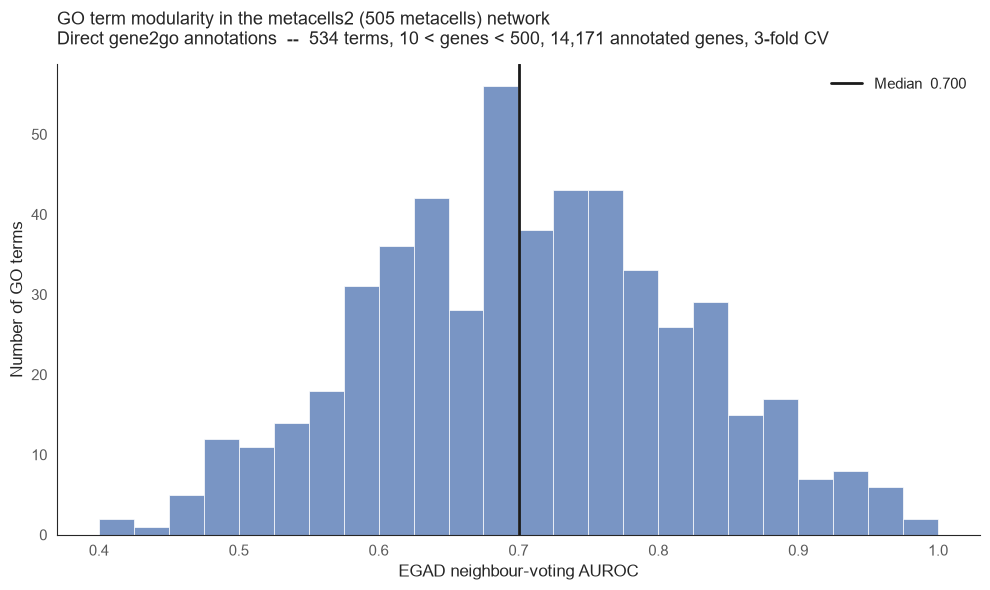

In [12]:
def plot_auroc_histogram(frame, subtitle):
    """One AUROC distribution per figure, on a fixed 0.4-1.0 axis so runs stack up."""
    median = float(frame["AUC"].median())
    sns.set_style("white")
    fig, ax = plt.subplots(figsize=(10, 6))

    sns.histplot(
        frame["AUC"],
        bins=24,
        binrange=(0.4, 1.0),
        color="#4C72B0",
        edgecolor="white",
        linewidth=0.5,
        ax=ax,
    )
    ax.axvline(
        median,
        color="#1A1A1A",
        linestyle="-",
        linewidth=2,
        label=f"Median  {median:.3f}",
    )

    ax.set_xlabel("EGAD neighbour-voting AUROC", fontsize=12)
    ax.set_ylabel("Number of GO terms", fontsize=12)
    ax.set_title(
        f"GO term modularity in the {NETWORK_LABEL} network\n"
        f"{subtitle}  --  {len(frame)} terms, {MIN_COUNT} < genes < {MAX_COUNT}, "
        f"{n_shared:,} annotated genes, {N_FOLD}-fold CV",
        fontsize=13,
        loc="left",
        pad=14,
    )
    ax.legend(loc="upper right", frameon=False, fontsize=11)
    ax.grid(False)
    sns.despine(ax=ax)
    ax.tick_params(labelsize=11, colors="#5A5A5A")
    fig.tight_layout()
    plt.show()


plot_auroc_histogram(results, "Direct gene2go annotations")

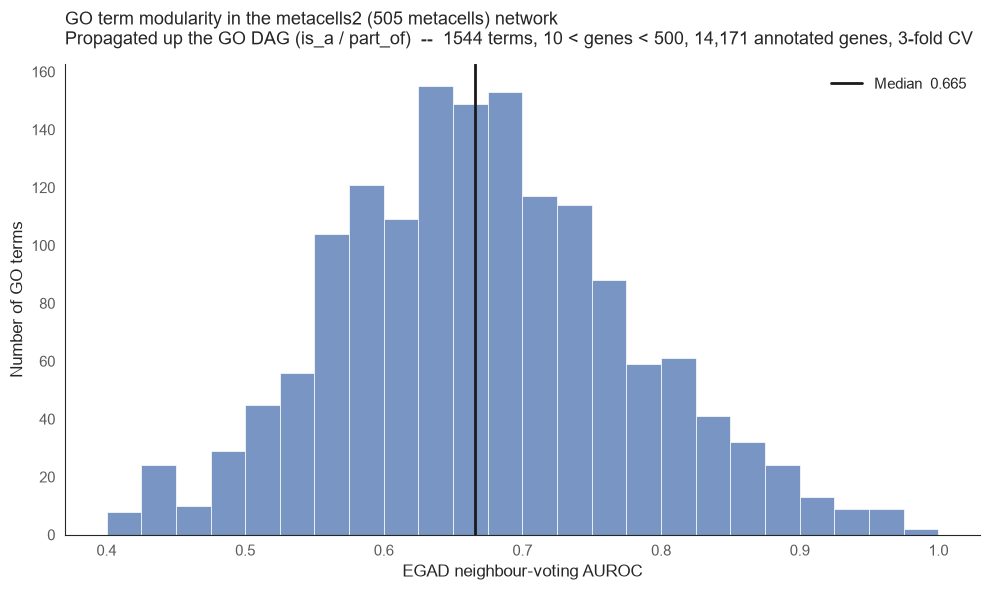

In [13]:
plot_auroc_histogram(results_propagated, "Propagated up the GO DAG (is_a / part_of)")

## Step 8 - does the newer annotation change the picture?

The question this notebook was written to answer. Two things could have moved: **coverage**
(how much of the network is annotated at all) and **score** (whether the terms that were
already scoreable look any more modular against a fresher annotation).

The AUROC comparison below is restricted to terms scored in *both* notebooks, so it is a
like-for-like measurement of the annotation, not of the term set.

In [14]:
phytozome = pd.read_csv(PHYTOZOME_RESULTS_PATH, index_col="GO")
phytozome_propagated = pd.read_csv(PHYTOZOME_PROPAGATED_PATH, index_col="GO")

# Counts and AUROCs share the table, so each row is formatted to its own precision.
coverage = pd.DataFrame(
    [
        (
            "annotated network genes",
            f"{PHYTOZOME_ANNOTATED_GENES:,} / {len(network_genes):,}",
            f"{n_shared:,} / {len(network_genes):,}",
        ),
        ("terms scored, direct", f"{len(phytozome):,}", f"{len(results):,}"),
        (
            "terms scored, propagated",
            f"{len(phytozome_propagated):,}",
            f"{len(results_propagated):,}",
        ),
        (
            "median AUROC, direct",
            f"{phytozome['AUC'].median():.3f}",
            f"{results['AUC'].median():.3f}",
        ),
        (
            "median AUROC, propagated",
            f"{phytozome_propagated['AUC'].median():.3f}",
            f"{results_propagated['AUC'].median():.3f}",
        ),
    ],
    columns=["", "Phytozome info_annot (2019)", "NCBI gene2go (current)"],
).set_index("")
print(coverage.to_string())

for label, old, new in [
    ("direct", phytozome, results),
    ("propagated", phytozome_propagated, results_propagated),
]:
    both = old[["AUC", "n_genes", "term_name"]].join(
        new[["AUC", "n_genes"]], lsuffix="_phytozome", rsuffix="_ncbi", how="inner"
    )
    change = both["AUC_ncbi"] - both["AUC_phytozome"]
    print(
        f"\n{label}: {len(both)} terms scored in both notebooks\n"
        f"  median AUROC {both['AUC_phytozome'].median():.3f} (Phytozome) -> "
        f"{both['AUC_ncbi'].median():.3f} (NCBI), median change {change.median():+.3f}\n"
        f"  {int((change > 0).sum())} improved, {int((change < 0).sum())} got worse\n"
        f"  median genes per term {int(both['n_genes_phytozome'].median())} -> "
        f"{int(both['n_genes_ncbi'].median())}"
    )
    if label == "direct":
        shared_direct = both.assign(AUC_change=change)

shared_direct.sort_values("AUC_change", key=abs, ascending=False).head(12)[
    [
        "term_name",
        "n_genes_phytozome",
        "n_genes_ncbi",
        "AUC_phytozome",
        "AUC_ncbi",
        "AUC_change",
    ]
]

                         Phytozome info_annot (2019) NCBI gene2go (current)
                                                                           
annotated network genes               8,836 / 22,123        14,171 / 22,123
terms scored, direct                              87                    534
terms scored, propagated                         400                  1,544
median AUROC, direct                           0.688                  0.700
median AUROC, propagated                       0.652                  0.665

direct: 68 terms scored in both notebooks
  median AUROC 0.678 (Phytozome) -> 0.676 (NCBI), median change -0.006
  31 improved, 37 got worse
  median genes per term 43 -> 49

propagated: 315 terms scored in both notebooks
  median AUROC 0.655 (Phytozome) -> 0.646 (NCBI), median change -0.003
  147 improved, 168 got worse
  median genes per term 42 -> 107


,term_name,n_genes_phytozome,n_genes_ncbi,AUC_phytozome,AUC_ncbi,AUC_change
GO,,,,,,
GO:0007017,microtubule-based process,25,19,0.777300,0.365635,-0.411665
GO:0006310,DNA recombination,46,11,0.491109,0.765070,0.273961
GO:0045454,cell redox homeostasis,128,30,0.588059,0.847242,0.259182
GO:0006694,steroid biosynthetic process,36,11,0.535542,0.291909,-0.243634
GO:0019898,extrinsic component of membrane,30,31,0.944622,0.732611,-0.212011
GO:0005622,intracellular anatomical structure,388,40,0.810387,0.615778,-0.194609
GO:0005874,microtubule,23,50,0.801824,0.645403,-0.156422
GO:0005618,cell wall,22,25,0.746029,0.594522,-0.151506
GO:0005783,endoplasmic reticulum,49,274,0.736490,0.589287,-0.147203


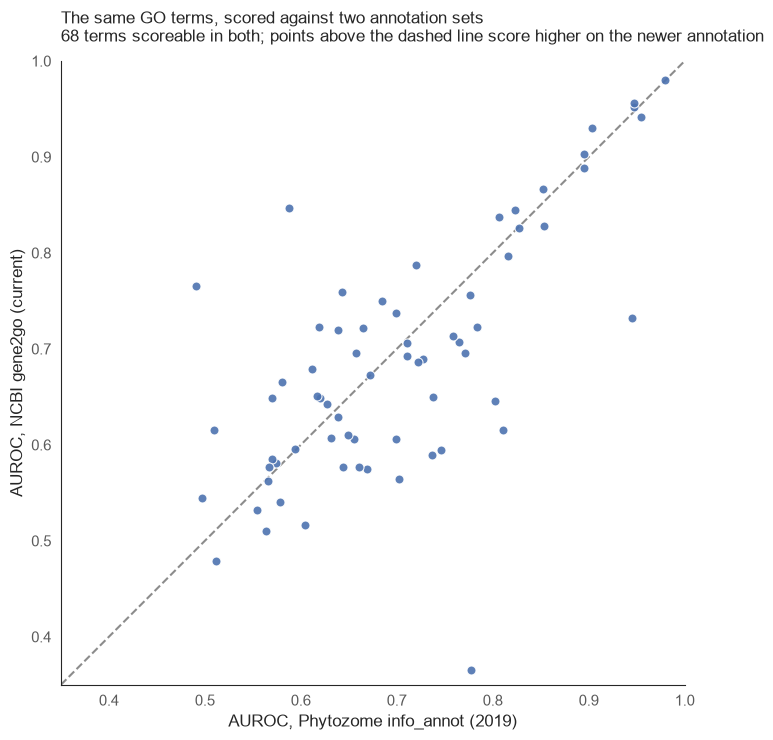

In [15]:
fig, ax = plt.subplots(figsize=(7.5, 7.5))

ax.plot(
    [0.35, 1.0], [0.35, 1.0], color="#8C8C8C", linestyle="--", linewidth=1.5, zorder=1
)
ax.scatter(
    shared_direct["AUC_phytozome"],
    shared_direct["AUC_ncbi"],
    s=42,
    color="#4C72B0",
    edgecolor="white",
    linewidth=0.8,
    alpha=0.9,
    zorder=2,
)

ax.set_xlim(0.35, 1.0)
ax.set_ylim(0.35, 1.0)
ax.set_aspect("equal")
ax.set_xlabel("AUROC, Phytozome info_annot (2019)", fontsize=12)
ax.set_ylabel("AUROC, NCBI gene2go (current)", fontsize=12)
ax.set_title(
    "The same GO terms, scored against two annotation sets\n"
    f"{len(shared_direct)} terms scoreable in both; points above the dashed line "
    "score higher on the newer annotation",
    fontsize=12,
    loc="left",
    pad=14,
)
ax.grid(False)
sns.despine(ax=ax)
ax.tick_params(labelsize=11, colors="#5A5A5A")
fig.tight_layout()
plt.show()

## Step 9 - guard cell genes

A closer look at one small, hand-picked gene set rather than a whole ontology:
`Guard_cell_genes.csv`, eight soybean orthologues of Arabidopsis guard cell genes.

The heat map shows the network's own edge weights between them. Those weights are **rank
standardised over the whole network**, so a value is a percentile, not a correlation: 0.5 is
the median edge in this network, 1.0 is the strongest, and the diagonal is a gene's self-edge
and always 1.

Genes on the list that the network cannot be asked about are reported rather than dropped
silently - the network only carries genes detected in >= 25% of metacells, so a real gene can
still be missing.

In [16]:
guard = pd.read_csv(GUARD_CELL_GENES_PATH)
guard[["locus", "label"]] = guard["GeneID"].str.split("-", n=1, expand=True)
guard["gene"] = guard["locus"] + ".Wm82.a4.v1"  # the network's ID form

# Three states, so a missing gene can be told apart from a bad ID: in the network; a real
# Wm82.a4 gene model that the detection filter dropped; or an ID matching no gene model.
guard["in_network"] = guard["gene"].isin(network_position.index)
guard["known_model"] = guard["gene"].map(glyma_to_locustag).isin(locus_to_geneid.index)

for _, row in guard.iterrows():
    if row["in_network"]:
        status = "in the network"
    elif row["known_model"]:
        status = "real gene model, but below the network's >=25% detection filter"
    else:
        status = "NOT a Wm82.a4 gene model -- check this ID"
    print(f"  {row['locus']:<18} {row['label']:<10} {status}")

present = guard[guard["in_network"]]
print(f"\n{len(present)} of {len(guard)} guard cell genes are in the network")

# The matrix is symmetric, so the loci go on the rows only -- repeating them across
# the columns just collides the tick labels.
guard_network = pd.DataFrame(
    read_network_subset(
        NETWORK_PATH, "network", network_position.loc[present["gene"]].to_numpy()
    ),
    index=(present["label"] + "\n" + present["locus"]).tolist(),
    columns=present["label"].tolist(),
)

off_diagonal = guard_network.values[~np.eye(len(present), dtype=bool)]
network_median = float(np.median(network.values))
print(
    f"  edges between them: median {np.median(off_diagonal):.3f}, "
    f"range {off_diagonal.min():.3f}-{off_diagonal.max():.3f}"
)
print(
    f"  median edge across the annotated network, for reference: {network_median:.3f}"
)

  Glyma.07G033500    ABCG40     real gene model, but below the network's >=25% detection filter
  Glyma.07G270800    HPCA1      in the network
  Glyma.03G13800     CPK32      NOT a Wm82.a4 gene model -- check this ID
  Glyma.19G119300    MYB60      real gene model, but below the network's >=25% detection filter
  Glyma.03G006600    MYB60      in the network
  Glyma.14G134100    AHA5       in the network
  Glyma.12G204400    TPC1       in the network
  Glyma.19G007700    CA1/CA4    in the network

5 of 8 guard cell genes are in the network


  edges between them: median 0.890, range 0.000-0.996
  median edge across the annotated network, for reference: 0.503


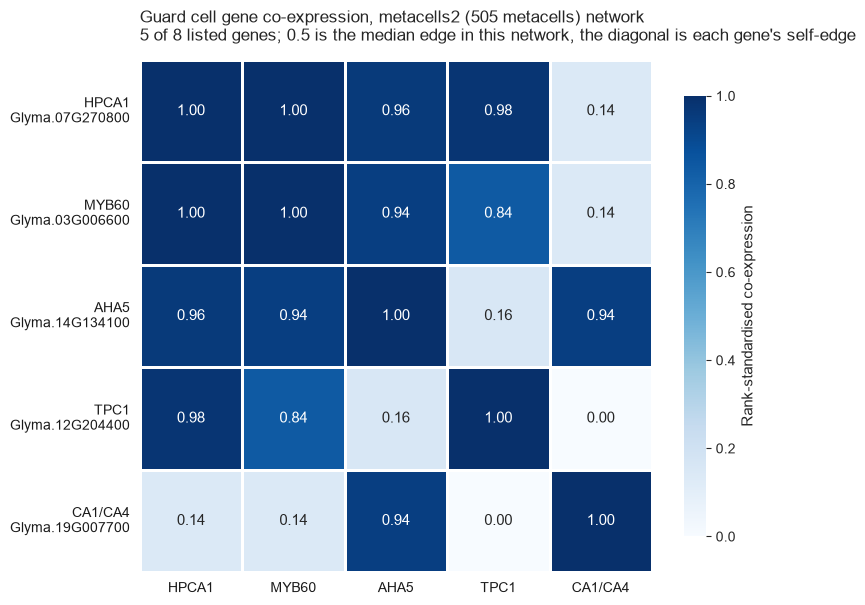

In [17]:
fig, ax = plt.subplots(figsize=(8, 6.5))

sns.heatmap(
    guard_network,
    vmin=0,
    vmax=1,
    cmap="Blues",
    annot=True,
    fmt=".2f",
    annot_kws={"fontsize": 11},
    linewidths=2,
    linecolor="white",
    square=True,
    cbar_kws={"label": "Rank-standardised co-expression", "shrink": 0.8},
    ax=ax,
)

ax.set_title(
    f"Guard cell gene co-expression, {NETWORK_LABEL} network\n"
    f"{len(present)} of {len(guard)} listed genes; 0.5 is the median edge in this network, "
    "the diagonal is each gene's self-edge",
    fontsize=12,
    loc="left",
    pad=14,
)
ax.tick_params(labelsize=10, colors="#1A1A1A", left=False, bottom=False)
plt.setp(ax.get_xticklabels(), rotation=0)
plt.setp(ax.get_yticklabels(), rotation=0)
ax.figure.axes[-1].yaxis.label.set_size(11)
fig.tight_layout()
plt.show()